In [1]:
import pandas as pd
from main import SatCLIPLightningModule
import location_encoder as LE
from temporal_encoding import Fourier, Direct
from tqdm import tqdm
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import numpy as np

from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from spatiotemporal_tools import *
import torch.nn.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Create the spatiotemporal train-test splits

In [4]:
# Load the GHCN dataset
ghcn_df = pd.read_csv('../data/ghcn_data/ghcn_2021_2026_temperature.csv')
print(len(ghcn_df))
ghcn_df.head()

104066815


,ID,Date,Element,Value,MFlag,QFlag,SFlag,OBS-TIME,Latitude,Longitude,Elevation,Name
0,AE000041196,20210101,TMAX,278,NaN,NaN,S,NaN,25.333,55.517,34.0,SHARJAH INTER. AIRP
1,AE000041196,20210101,PRCP,0,D,NaN,S,NaN,25.333,55.517,34.0,SHARJAH INTER. AIRP
2,AEM00041194,20210101,TMAX,266,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL
3,AEM00041194,20210101,TMIN,178,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL
4,AEM00041194,20210101,PRCP,0,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL


In [5]:
ghcn_df.head()

,ID,Date,Element,Value,MFlag,QFlag,SFlag,OBS-TIME,Latitude,Longitude,Elevation,Name
0,AE000041196,20210101,TMAX,278,NaN,NaN,S,NaN,25.333,55.517,34.0,SHARJAH INTER. AIRP
1,AE000041196,20210101,PRCP,0,D,NaN,S,NaN,25.333,55.517,34.0,SHARJAH INTER. AIRP
2,AEM00041194,20210101,TMAX,266,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL
3,AEM00041194,20210101,TMIN,178,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL
4,AEM00041194,20210101,PRCP,0,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL


In [6]:
# Filter GHCN to quality controlled data
ghcn_qc_temp_df = ghcn_df[(ghcn_df["Element"]=="TMAX") & (ghcn_df["QFlag"].isna())]
ghcn_qc_temp_df['Date'] = pd.to_datetime(ghcn_qc_temp_df['Date'], format="%Y%m%d")
ghcn_qc_temp_df['DayOfYear'] = (ghcn_qc_temp_df['Date'].dt.dayofyear - 1) / 364.0
ghcn_qc_temp_df.head()


/tmp/ipykernel_46465/4077555395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ghcn_qc_temp_df['Date'] = pd.to_datetime(ghcn_qc_temp_df['Date'], format="%Y%m%d")
/tmp/ipykernel_46465/4077555395.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ghcn_qc_temp_df['DayOfYear'] = (ghcn_qc_temp_df['Date'].dt.dayofyear - 1) / 364.0


,ID,Date,Element,Value,MFlag,QFlag,SFlag,OBS-TIME,Latitude,Longitude,Elevation,Name,DayOfYear
0,AE000041196,2021-01-01,TMAX,278,NaN,NaN,S,NaN,25.3330,55.5170,34.0,SHARJAH INTER. AIRP,0.0
2,AEM00041194,2021-01-01,TMAX,266,NaN,NaN,S,NaN,25.2550,55.3640,10.4,DUBAI INTL,0.0
5,AEM00041217,2021-01-01,TMAX,262,NaN,NaN,S,NaN,24.4330,54.6510,26.8,ABU DHABI INTL,0.0
7,AEM00041218,2021-01-01,TMAX,250,NaN,NaN,S,NaN,24.2620,55.6090,264.9,AL AIN INTL,0.0
67,ASN00031108,2021-01-01,TMAX,290,NaN,NaN,a,NaN,-17.1347,145.4281,594.0,WALKAMIN RESEARCH STATION,0.0


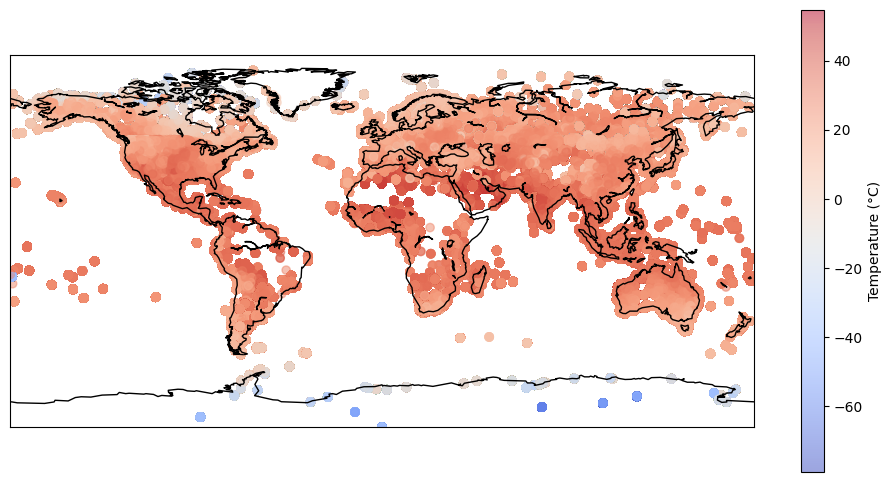

In [ ]:
# Plot the temperatures on a map
fig, ax = plt.subplots(figsize=(12, 6))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()
sc = ax.scatter(ghcn_qc_temp_df['Longitude'].values, ghcn_qc_temp_df['Latitude'].values, c=ghcn_qc_temp_df['Value'].values/10, cmap='coolwarm', marker='o', alpha=0.5)
fig.colorbar(sc, label='Temperature (°C)', ax=ax)

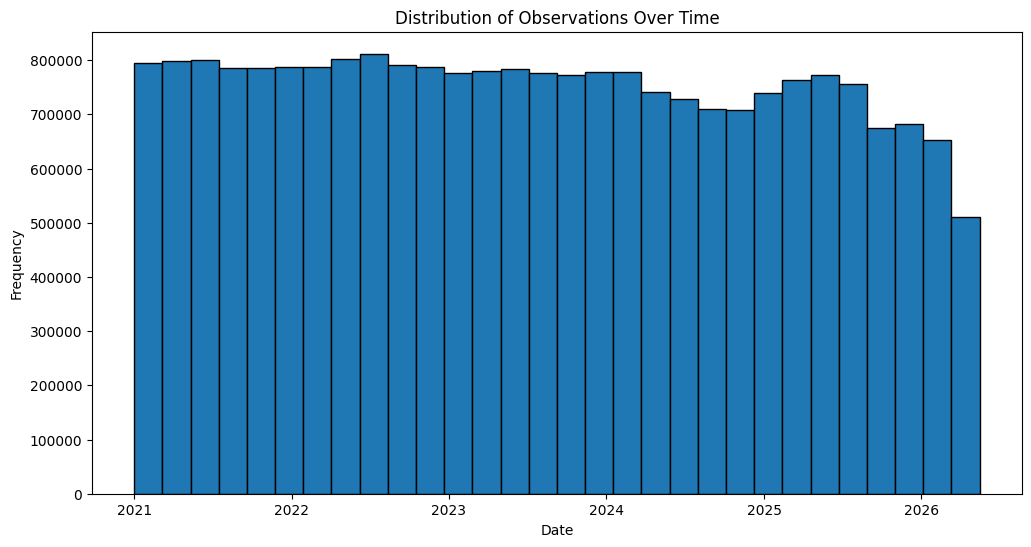

In [7]:
# Plot histogram of observations over time for all stations
plt.figure(figsize=(12, 6))
plt.hist(ghcn_qc_temp_df['Date'], bins=30, edgecolor='black')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.title('Distribution of Observations Over Time')
plt.show()

In [94]:
# Create the spatiotemporal checkerboard splits for the GHCN dataset
delta_degree = 16
delta_day = 30
coords = torch.tensor(ghcn_qc_temp_df[['Longitude', 'Latitude', 'DayOfYear']].values, dtype=torch.float32)
print(coords.shape)

splits = checkerboard_splits(coords[:, :2], torch.tensor([delta_degree, delta_degree]))
ghcn_qc_temp_df['split'] = splits

torch.Size([22614137, 3])


/tmp/ipykernel_46465/2809065200.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ghcn_qc_temp_df['split'] = splits


In [ ]:
# Plot the splits on a map
fig, ax = plt.subplots(figsize=(12, 6))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()
# Parallels (Latitudes) range from -90 to 90
m.drawparallels(np.arange(-90, 90, 30), labels=[True, True, False, False])

# Meridians (Longitudes) range from 0 to 360 (or -180 to 180 depending on projection)
m.drawmeridians(np.arange(0, 360, 30), labels=[False, False, True, True])

sc = ax.scatter(ghcn_qc_temp_df['Longitude'].values, ghcn_qc_temp_df['Latitude'].values, c=splits, cmap='coolwarm', marker='o', alpha=0.5)
fig.colorbar(sc, label='Split', ax=ax)

In [ ]:
# Plot GIF of the dataset over time
# Make a gif over time of the dataset
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
import io
from tqdm import tqdm

frames = []

days_win = 30

for date in tqdm(ghcn_qc_temp_df['Date'].unique()):
    # Find images within a window of days
    df_window = ghcn_qc_temp_df[(ghcn_qc_temp_df['Date'] == date)]

    # cs = np.array([np.array(x)/255.0 for x in df_window['avg_color'].values])
    # cs = np.minimum(cs, 1.0)

    # Plot the average colors of the images in this window on the map
    fig, ax = plt.subplots(1,1, figsize=(10, 5))

    m = Basemap(projection='cyl', resolution='c', ax=ax)
    m.drawcoastlines()

    sc = ax.scatter(df_window['Longitude'].values, df_window['Latitude'].values, c=df_window['Value'].values/10, cmap='coolwarm', marker='o', alpha=0.5)
    # sc = ax.scatter(df_window['x'].values, df_window['y'].values, s=5, c=cs, label="Location")
    ax.set_title(f"Date: {date.strftime('%Y-%m-%d')}")
    ax.legend()

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

# Save as GIF
frames[0].save('ghcn_temporal_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)

Text(0.5, 1.0, 'Temperature Over Time for Station DUBLIN PHOENIX PARK')

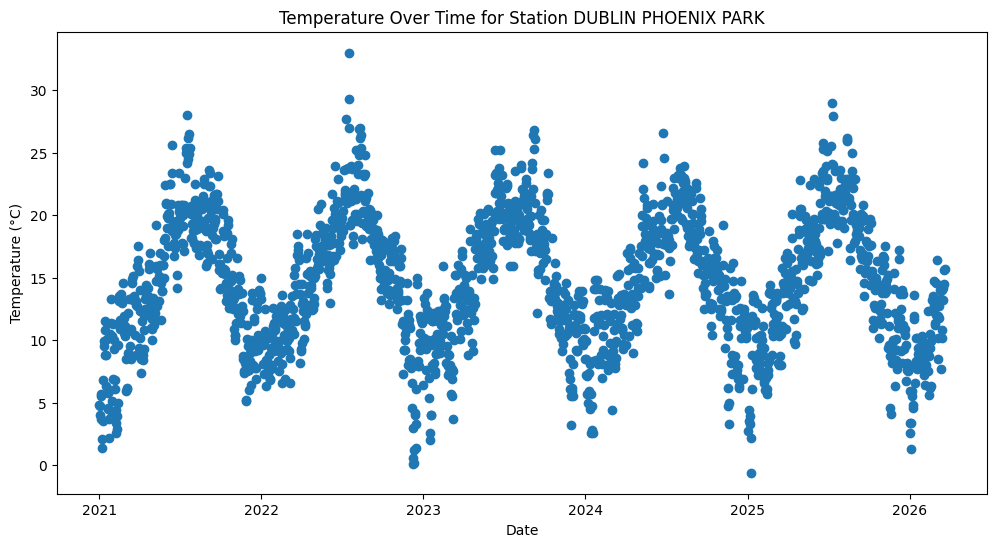

In [95]:
# Plot the distribution of temperatures over time for a randomly selected station
import random
random_station = random.choice(ghcn_qc_temp_df['Name'].unique())
station_df = ghcn_qc_temp_df[ghcn_qc_temp_df['Name']== random_station]
plt.figure(figsize=(12, 6))
plt.scatter(station_df['Date'], station_df['Value']/10, marker='o', linestyle='-', label=f'Station: {random_station}')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Over Time for Station {random_station}')

# Perform fine-tuning for a location encoder

In [96]:
# Load a pre-trained spatio-temporal SatCLIP encoder
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-temporal-55k-temporalsplits-fixednormalizeddayofyear/satclip-fixed-normalized-day-of-year/checkpoints/last.ckpt'
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-satcliploss-100k/satclip-s2-satcliploss-100k/checkpoints/last-v2.ckpt'
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-softloss-100k/satclip-s2-softloss-100k/checkpoints/last.ckpt'
ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-satcliploss-1M/satclip-s2-satcliploss-1M/checkpoints/last-v1.ckpt'

lightning_model = SatCLIPLightningModule.load_from_checkpoint(ckpt_path)

lightning_model.eval()
spatiotemporal_enc = lightning_model.model.location
visual_enc = lightning_model.model.visual

using pretrained moco vit16
using loss function: satclip_loss
using temporal model: True


In [97]:
# Get the embeddings for the GHCN dataset using the pre-trained spatio-temporal SatCLIP encoder
train_split = 0

# Get the locations for the train split
train = ghcn_qc_temp_df[ghcn_qc_temp_df['split'] == train_split][['Longitude', 'Latitude', 'DayOfYear', 'Value']].values
test = ghcn_qc_temp_df[ghcn_qc_temp_df['split'] != train_split][['Longitude', 'Latitude', 'DayOfYear', 'Value']].values

# Get a sample of the train and test splits
# train_sample = train
# test_sample = test
train_sample = train[np.random.choice(train.shape[0], size=100000, replace=False)]
test_sample = test[np.random.choice(test.shape[0], size=100000, replace=False)]

# Normalize temperature values to be between 0 and 1
# temp_min = ghcn_qc_temp_df['Value'].min()
# temp_max = ghcn_qc_temp_df['Value'].max()

# train_sample[:, 3] = (train_sample[:, 3] - temp_min) / (temp_max - temp_min)
# test_sample[:, 3] = (test_sample[:, 3] - temp_min) / (temp_max - temp_min)

# Sample the embeddings for the train split
train_coords = torch.tensor(train_sample[:, :3], dtype=torch.float64).to(device)
test_coords = torch.tensor(test_sample[:, :3], dtype=torch.float64).to(device)

spatiotemporal_enc = spatiotemporal_enc.to(device)
with torch.no_grad():
    train_embeddings = spatiotemporal_enc(train_coords).detach()
    test_embeddings = spatiotemporal_enc(test_coords).detach()

In [81]:
print(f"Train embeddings shape: {train_embeddings.shape}")

Train embeddings shape: torch.Size([100000, 256])


In [ ]:
# # Linear probe on the train embeddings to predict the temperature values
# linear_probe = nn.Linear(train_embeddings.shape[1], 1, dtype=torch.float64).to(device)

# # MLP probe on the train embeddings to predict the temperature values
# mlp_probe = nn.Sequential(    
#     nn.Linear(train_embeddings.shape[1], 128, dtype=torch.float64),
#     nn.ReLU(),
#     nn.Linear(128, 1, dtype=torch.float64)
# ).to(device)

# # Create a DataLoader for the train embeddings and values
# train_dataset = torch.utils.data.TensorDataset(train_embeddings, torch.tensor(train_sample[:, 3], dtype=torch.float64).unsqueeze(1))
# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# # Test dataloader
# test_dataset = torch.utils.data.TensorDataset(test_embeddings, torch.tensor(test_sample[:, 3], dtype=torch.float64).unsqueeze(1))
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# # Train loop
# linear_probe.train()
# optimizer = torch.optim.Adam(linear_probe.parameters(), lr=1e-3)
# mseloss = nn.MSELoss()

# for epoch in tqdm(range(10)):
#     for batch in train_loader:
#         embeddings, values = batch
#         values = values.to(device)
#         optimizer.zero_grad()
#         predictions = linear_probe(embeddings)
#         loss = mseloss(predictions, values)
#         loss.backward()
#         optimizer.step()

# test_predictions = linear_probe(test_embeddings).cpu().detach().numpy()

# test_loss = torch.sqrt(F.mse_loss(torch.tensor(test_predictions), torch.tensor(test_sample[:, 3], dtype=torch.float32).unsqueeze(1))).item()
# print(f'Test RMSE: {test_loss/10} °C')  # Divide by 10 to convert from tenths of degrees Celsius to degrees Celsius

100%|██████████| 10/10 [01:14<00:00,  7.47s/it]

Test RMSE: 9.168397280960646 °C


In [82]:
print(train_sample[:5])

[[ 2.33953000e+01  6.72050000e+01  1.59340659e-01  2.00000000e+00]
 [-1.12016900e+02  4.11942000e+01  6.75824176e-01  3.83000000e+02]
 [-1.09220000e+02  3.36900000e+01  1.73076923e-01  9.50000000e+01]
 [-1.11250000e+02  6.57500000e+01  2.22527473e-01 -2.46000000e+02]
 [-9.75514000e+01  4.11844000e+01  1.81318681e-01  2.06000000e+02]]


In [94]:
# Clear GPU memory
torch.cuda.empty_cache()

In [98]:
import torch.nn as nn

# Create a DataLoader for the train embeddings and values
train_dataset = torch.utils.data.TensorDataset(train_embeddings, torch.tensor(train_sample[:, 3], dtype=torch.float64).unsqueeze(1))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Test dataloader
test_dataset = torch.utils.data.TensorDataset(test_embeddings, torch.tensor(test_sample[:, 3], dtype=torch.float64).unsqueeze(1))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_dim, dim_hidden, num_layers, out_dims):
        super(MLP, self).__init__()

        layers = []
        layers += [nn.Linear(input_dim, dim_hidden, bias=True), nn.ReLU()] # Input layer
        layers += [nn.Linear(dim_hidden, dim_hidden, bias=True), nn.ReLU()] * num_layers # Hidden layers
        layers += [nn.Linear(dim_hidden, out_dims, bias=True)] # Output layer

        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)
    
pred_model = MLP(input_dim=256, dim_hidden=64, num_layers=2, out_dims=1).double().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(pred_model.parameters(), lr=1e-3)

losses = []
epochs = 200

for epoch in range(epochs):
  pred_model.train()
  running_loss = 0.0

  for batch in train_loader:
    optimizer.zero_grad()
    embeddings, values = batch
    # Forward pass
    y_pred = pred_model(embeddings.to(device))
    # Compute the loss
    loss = criterion(y_pred, values.to(device))
    # Backward pass
    loss.backward()
    # Update the parameters
    optimizer.step()
    # Append the loss to the list
    losses.append(loss.item())

    running_loss += loss.item() * embeddings.size(0)  # Multiply by batch size to get total loss for the batch

  epoch_loss = running_loss / len(train_loader.dataset)
  
  if (epoch) % 10 == 0:
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 4967.2285
Epoch 11, Loss: 2897.2209
Epoch 21, Loss: 2811.0323
Epoch 31, Loss: 2770.6843
Epoch 41, Loss: 2743.9485
Epoch 51, Loss: 2721.6107
Epoch 61, Loss: 2705.0055
Epoch 71, Loss: 2687.6866
Epoch 81, Loss: 2677.3131
Epoch 91, Loss: 2672.9064
Epoch 101, Loss: 2658.4817
Epoch 111, Loss: 2655.0450
Epoch 121, Loss: 2645.3837
Epoch 131, Loss: 2640.1689
Epoch 141, Loss: 2628.8154
Epoch 151, Loss: 2630.2286
Epoch 161, Loss: 2624.7271
Epoch 171, Loss: 2618.1611
Epoch 181, Loss: 2614.8715
Epoch 191, Loss: 2616.1635


In [99]:
# Run test
preds = []
actuals = []

with torch.no_grad():
  pred_model.eval()

  for batch in test_loader:
    embeddings, values = batch
    y_pred_test = pred_model(embeddings.double().to(device))
    preds.extend(y_pred_test.cpu().detach().numpy())
    actuals.extend(values.double().to(device).cpu().detach().numpy())

# Print test loss
print(f'Test loss: {criterion(torch.tensor(preds), torch.tensor(actuals)).item()}')

# Print test RMSE
test_rmse = torch.sqrt(F.mse_loss(torch.tensor(preds), torch.tensor(actuals))).item()
print(f'Test RMSE: {test_rmse/10} °C')

Test loss: 3581.316848068554
Test RMSE: 5.984410453894815 °C


Text(0.5, 1.0, 'Predicted vs Actual Temperatures for Test Set')

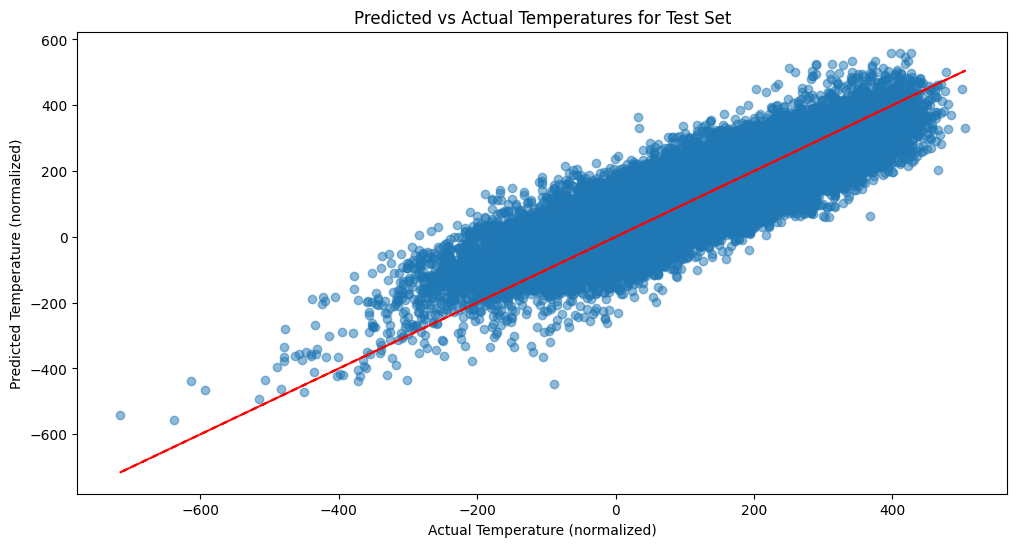

In [100]:
# Plot predicted vs actual temperatures for the test set
plt.figure(figsize=(12, 6))
plt.scatter(actuals, preds, alpha=0.5)
plt.plot(actuals, actuals, color='red', linestyle='--')  # Line y=x for reference
plt.xlabel('Actual Temperature (normalized)')
plt.ylabel('Predicted Temperature (normalized)')
plt.title('Predicted vs Actual Temperatures for Test Set')

Text(0.5, 1.0, 'Predicted vs Actual Temperature Over Time for Station SOLA/VANUA LAVA ISL')

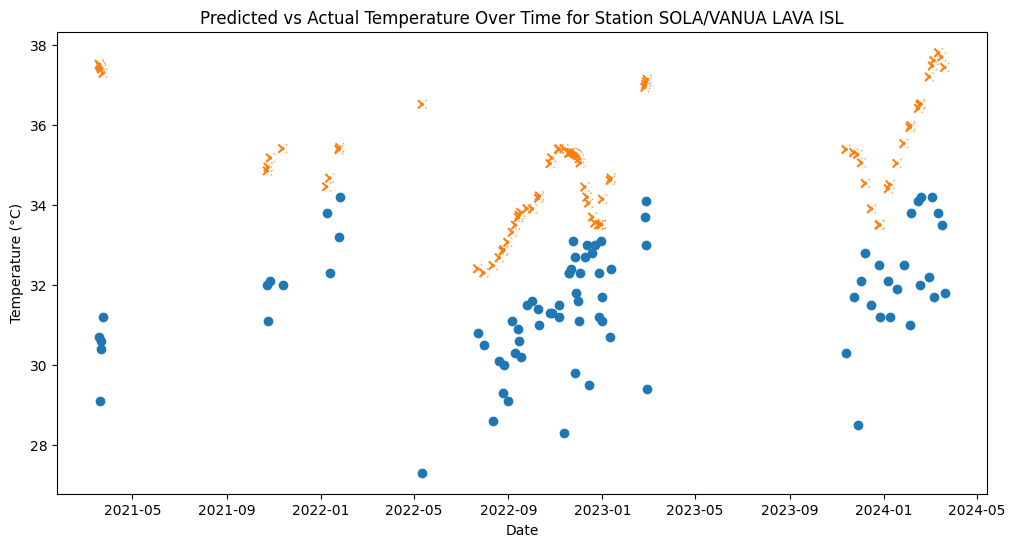

In [119]:
# For a randomly selected station in the test set, plot the predicted vs actual temperatures over time
random_station = random.choice(ghcn_qc_temp_df[ghcn_qc_temp_df['split'] != train_split]['Name'].unique())
# random_station = random.choice(ghcn_qc_temp_df[ghcn_qc_temp_df['split'] == train_split]['Name'].unique())
# random_station = random.choice(ghcn_qc_temp_df['Name'].unique())
station_df = ghcn_qc_temp_df[ghcn_qc_temp_df['Name']== random_station]
# Get the embeddings for this station
station_coords = torch.tensor(station_df[['Latitude', 'Longitude', 'DayOfYear']].values, dtype=torch.float64).to(device)
station_embeddings = spatiotemporal_enc(station_coords).detach()
# Get the predicted temperatures for this station
station_predictions = pred_model(station_embeddings).cpu().detach().numpy()

plt.figure(figsize=(12, 6))
plt.scatter(station_df['Date'], station_df['Value']/10, marker='o', linestyle='-', label=f'Actual: {random_station}')
plt.scatter(station_df['Date'], station_predictions/10, marker='x', linestyle='--', label=f'Predicted: {random_station}')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title(f'Predicted vs Actual Temperature Over Time for Station {random_station}')

In [ ]:
# Plot residuals for the test set for first day of each month in GIF format
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
import io
from tqdm import tqdm

In [104]:
# Create a DataLoader for the train embeddings and values
train_dataset = torch.utils.data.TensorDataset(train_coords, torch.tensor(train_sample[:, 3], dtype=torch.float64).unsqueeze(1))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Test dataloader
test_dataset = torch.utils.data.TensorDataset(test_coords, torch.tensor(test_sample[:, 3], dtype=torch.float64).unsqueeze(1))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

simple_model = MLP(input_dim=3, dim_hidden=64, num_layers=2, out_dims=1).double().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(simple_model.parameters(), lr=1e-3)

losses = []
epochs = 200

print(f"Train shape: {train_dataset.tensors[0].shape}")

for epoch in range(epochs):
  simple_model.train()
  running_loss = 0.0

  for batch in train_loader:
    optimizer.zero_grad()
    coords, values = batch
    # Forward pass
    y_pred = simple_model(coords.to(device))
    # Compute the loss
    loss = criterion(y_pred, values.to(device))
    # Backward pass
    loss.backward()
    # Update the parameters
    optimizer.step()
    # Append the loss to the list
    losses.append(loss.item())

    running_loss += loss.item() * coords.size(0)  # Multiply by batch size to get total loss for the batch

  epoch_loss = running_loss / len(train_loader.dataset)
  
  if (epoch) % 10 == 0:
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")

Train shape: torch.Size([100000, 3])
Epoch 1, Loss: 17514.5491
Epoch 11, Loss: 4142.3879
Epoch 21, Loss: 3634.1006
Epoch 31, Loss: 3469.1806
Epoch 41, Loss: 3443.2812
Epoch 51, Loss: 3424.6166
Epoch 61, Loss: 3380.1825
Epoch 71, Loss: 3373.9533
Epoch 81, Loss: 3372.1155
Epoch 91, Loss: 3376.9932
Epoch 101, Loss: 3336.7869
Epoch 111, Loss: 3343.0574
Epoch 121, Loss: 3322.4720
Epoch 131, Loss: 3326.4795
Epoch 141, Loss: 3332.2554
Epoch 151, Loss: 3317.9208
Epoch 161, Loss: 3349.0843
Epoch 171, Loss: 3334.8699
Epoch 181, Loss: 3313.7292
Epoch 191, Loss: 3348.1290


In [105]:
# Run test
preds = []
actuals = []

with torch.no_grad():
  simple_model.eval()

  for batch in test_loader:
    coords, values = batch
    y_pred_test = simple_model(coords.to(device))
    preds.extend(y_pred_test.cpu().detach().numpy())
    actuals.extend(values.to(device).cpu().detach().numpy())

# Print test loss
print(f'Test loss: {criterion(torch.tensor(preds), torch.tensor(actuals)).item()}')

# Print test RMSE
test_rmse = torch.sqrt(F.mse_loss(torch.tensor(preds), torch.tensor(actuals))).item()
print(f'Test RMSE: {test_rmse/10} °C')

Test loss: 3773.0422683775364
Test RMSE: 6.14250947771148 °C


Text(0.5, 1.0, 'Predicted vs Actual Temperatures for Test Set')

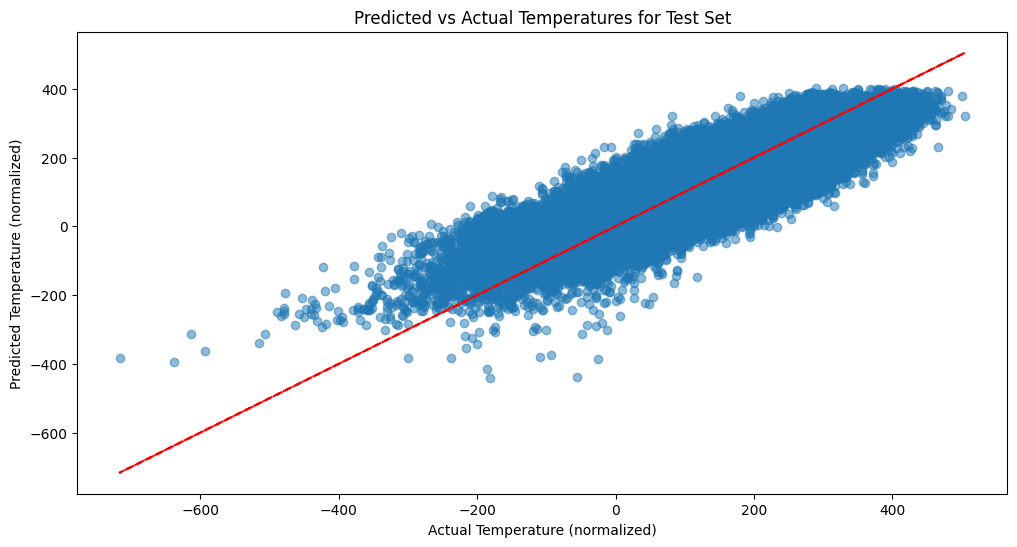

In [106]:
# Plot predicted vs actual temperatures for the test set
plt.figure(figsize=(12, 6))
plt.scatter(actuals, preds, alpha=0.5)
plt.plot(actuals, actuals, color='red', linestyle='--')  # Line y=x for reference
plt.xlabel('Actual Temperature (normalized)')
plt.ylabel('Predicted Temperature (normalized)')
plt.title('Predicted vs Actual Temperatures for Test Set')

Text(0.5, 1.0, 'Predicted vs Actual Temperature Over Time for Station SOLA/VANUA LAVA ISL')

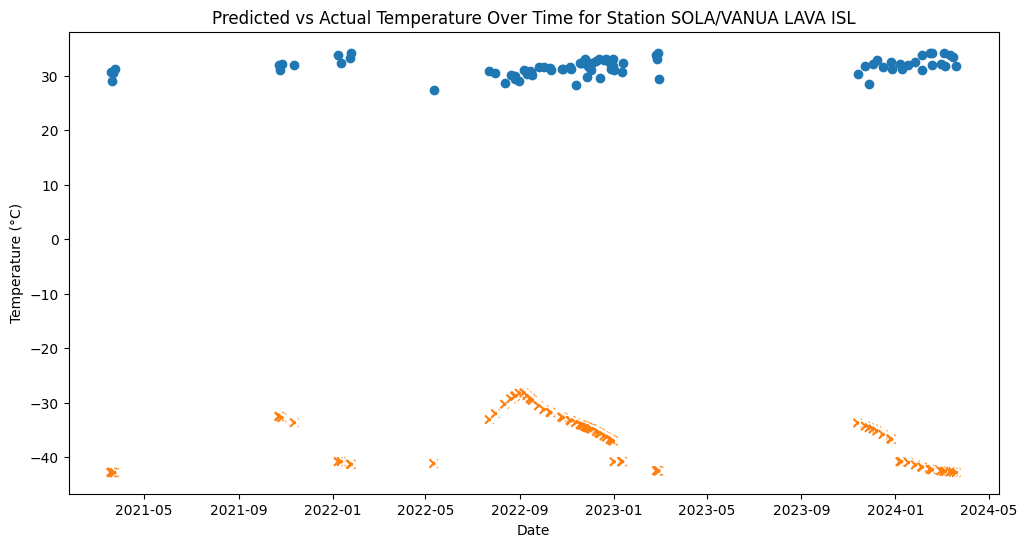

In [120]:
station_df = ghcn_qc_temp_df[ghcn_qc_temp_df['Name']== random_station]
# Get the embeddings for this station
station_coords = torch.tensor(station_df[['Latitude', 'Longitude', 'DayOfYear']].values, dtype=torch.float64).to(device)
# Get the predicted temperatures for this station
station_predictions = simple_model(station_coords.to(device)).cpu().detach().numpy()

plt.figure(figsize=(12, 6))
plt.scatter(station_df['Date'], station_df['Value']/10, marker='o', linestyle='-', label=f'Actual: {random_station}')
plt.scatter(station_df['Date'], station_predictions/10, marker='x', linestyle='--', label=f'Predicted: {random_station}')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title(f'Predicted vs Actual Temperature Over Time for Station {random_station}')

In [91]:
test_predictions = linear_probe(test_embeddings).detach().cpu().numpy()

test_loss = torch.sqrt(F.mse_loss(torch.tensor(test_predictions), torch.tensor(test_sample[:, 3], dtype=torch.float32).unsqueeze(1))).item()
print(f'Test RMSE: {test_loss/10} °C')  # Divide by 10 to convert from tenths of degrees Celsius to degrees Celsius

NameError: name 'linear_probe' is not defined

In [ ]:
# Can you do better just via linear probing directly on the raw coordinates (latitude, longitude, day of year) without using the pre-trained spatio-temporal SatCLIP encoder?

linear_model = nn.Linear(3, 1, dtype=torch.float64).to(device)

train_dataset = torch.utils.data.TensorDataset(train_coords, torch.tensor(train_sample[:, 3], dtype=torch.float64).unsqueeze(1))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(test_coords, torch.tensor(test_sample[:, 3], dtype=torch.float64).unsqueeze(1))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

optimizer = torch.optim.Adam(linear_model.parameters(), lr=1e-3)
mseloss = nn.MSELoss()

for epoch in tqdm(range(10)):
    for batch in train_loader:
        coords, values = batch
        values = values.to(device)
        optimizer.zero_grad()
        predictions = linear_model(coords)
        loss = mseloss(predictions, values)
        loss.backward()
        optimizer.step()

test_predictions = linear_model(test_coords).detach().cpu().numpy()

test_loss = torch.sqrt(F.mse_loss(torch.tensor(test_predictions), torch.tensor(test_sample[:, 3], dtype=torch.float32).unsqueeze(1))).item()
print(f'Test RMSE (raw coordinates): {test_loss/10} °C')

100%|██████████| 10/10 [01:12<00:00,  7.30s/it]

Test RMSE (raw coordinates): 11.87023930410822 °C


In [ ]:
test_predictions = linear_model(test_coords).detach().cpu().numpy()

test_loss = torch.sqrt(F.mse_loss(torch.tensor(test_predictions), torch.tensor(test_sample[:, 3], dtype=torch.float32).unsqueeze(1))).item()
print(f'Test RMSE (raw coordinates): {test_loss/10} °C')

Test RMSE (raw coordinates): 11.976349799040019 °C


Text(0, 0.5, 'Predicted Temperature (°C)')

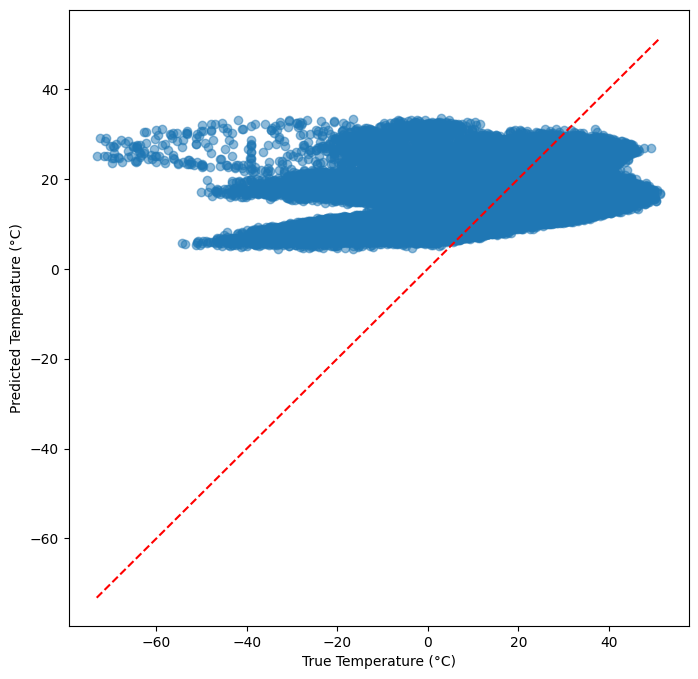

In [ ]:
# Plot the test predictions vs the true values
plt.figure(figsize=(8, 8))
plt.scatter(test_sample[:, 3]/10, test_predictions/10, alpha=0.5)
plt.plot([test_sample[:, 3].min()/10, test_sample[:, 3].max()/10], [test_sample[:, 3].min()/10, test_sample[:, 3].max()/10], 'r--')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:58<00:00,  1.17s/it]

Test RMSE (fine-tuned): 6.348270060423048 °C


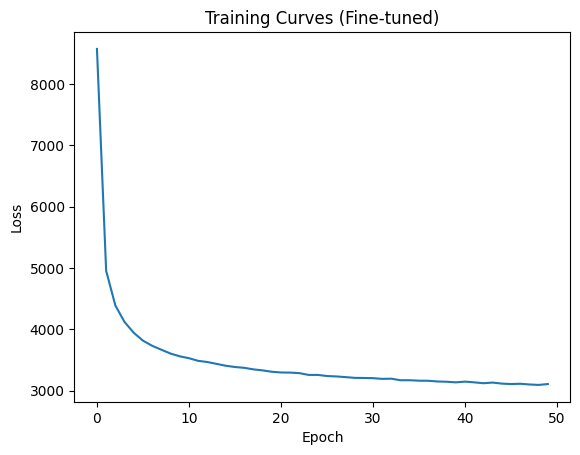

In [ ]:
# Compare fine-tuning vs. training an MLP from scratch on the raw coordinates (latitude, longitude, day of year) without using the pre-trained spatio-temporal SatCLIP encoder.

fine_tune_model = nn.Sequential(
    nn.Linear(train_embeddings.shape[1], 64, dtype=torch.float64),
    nn.ReLU(),
    nn.Linear(64, 64, dtype=torch.float64),
    nn.ReLU(),
    nn.Linear(64, 1, dtype=torch.float64)
).to(device)

# Create a DataLoader for the train embeddings and values
train_dataset = torch.utils.data.TensorDataset(train_embeddings.to(device), torch.tensor(train_sample[:, 3], dtype=torch.float64).unsqueeze(1).to(device))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Test dataloader
test_dataset = torch.utils.data.TensorDataset(test_embeddings.to(device), torch.tensor(test_sample[:, 3], dtype=torch.float64).unsqueeze(1).to(device))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Train loop for fine-tuning
fine_tune_model.train()
optimizer = torch.optim.Adam(fine_tune_model.parameters(), lr=1e-3)
mseloss = nn.MSELoss()

train_losses = []

for epoch in tqdm(range(50)):

    loss_epoch = 0.0
    for batch in train_loader:
        embeddings, values = batch
        optimizer.zero_grad()
        predictions = fine_tune_model(embeddings)
        loss = mseloss(predictions, values)
        loss.backward()
        optimizer.step()
        loss_epoch += loss.item()
    train_losses.append(loss_epoch / len(train_loader))
    
# Evaluate the fine-tuned model
fine_tune_model.eval()
test_predictions = fine_tune_model(test_embeddings.to(device)).detach().cpu().numpy()

test_loss = torch.sqrt(F.mse_loss(torch.tensor(test_predictions), torch.tensor(test_sample[:, 3], dtype=torch.float32).unsqueeze(1))).item()
print(f'Test RMSE (fine-tuned): {test_loss/10} °C')


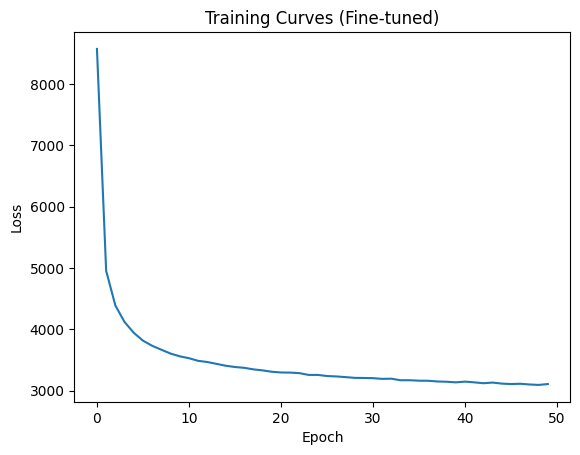

Text(0, 0.5, 'Predicted Temperature (°C)')

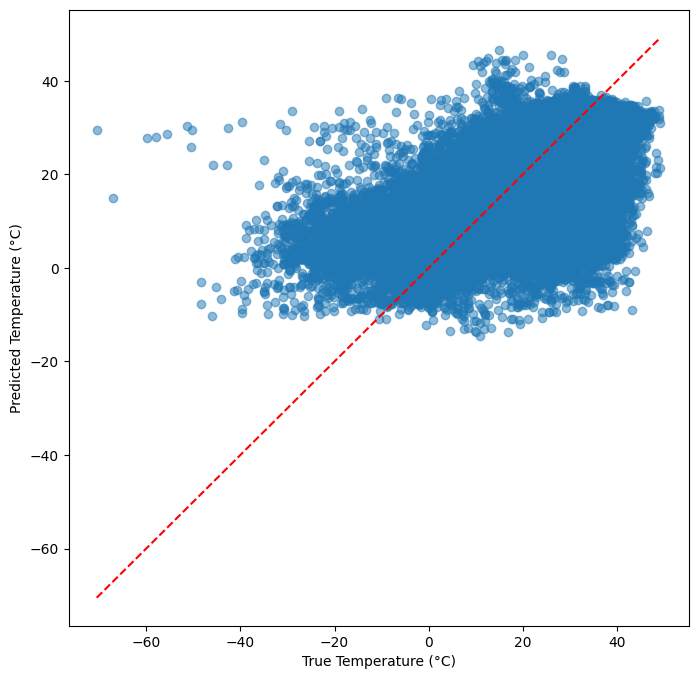

In [ ]:
# Plot training curves for the fine-tuned model
plt.plot([epoch for epoch in range(50)], train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves (Fine-tuned)')
plt.show()

# prediction vs true values for fine-tuned model
plt.figure(figsize=(8, 8))
plt.scatter(test_sample[:, 3]/10, test_predictions/10, alpha=0.5)
plt.plot([test_sample[:, 3].min()/10, test_sample[:, 3].max()/10], [test_sample[:, 3].min()/10, test_sample[:, 3].max()/10], 'r--')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')